## Setup: Environment and Imports

In [1]:
# Colab Setup (run this first if in Colab)
import sys
from pathlib import Path

# Check if in Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("🔧 Running in Google Colab - setting up environment...")
    
    # Clone repository
    if not Path('/content/PIDSE').exists():
        print("📥 Cloning PIDSE repository...")
        !git clone https://github.com/mjmoosavizade/PIDSE.git /content/PIDSE
    else:
        print("✓ Repository already cloned")
    
    # Change to repo directory
    import os
    os.chdir('/content/PIDSE')
    
    # Install dependencies
    print("📦 Installing dependencies...")
    %pip install -q torch numpy scipy matplotlib pandas pyyaml
    
    print("✅ Colab setup complete!")
else:
    print("Running locally")

🔧 Running in Google Colab - setting up environment...
✓ Repository already cloned
📦 Installing dependencies...
✅ Colab setup complete!
✅ Colab setup complete!


In [2]:
# Import required libraries
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
from copy import deepcopy
from typing import Dict, List, Tuple
from pathlib import Path
import sys
import os
from datetime import datetime

# Clear any cached module imports (important for Colab)
if 'pidse' in sys.modules:
    import importlib
    for module_name in list(sys.modules.keys()):
        if module_name.startswith('pidse'):
            del sys.modules[module_name]

# Set up path to PIDSE module
current_dir = Path.cwd()
notebook_dir = Path(__file__).parent if '__file__' in globals() else current_dir

# Search for pidse directory
REPO_ROOT = None
for path in [current_dir, notebook_dir, current_dir.parent, notebook_dir.parent]:
    if (path / 'pidse').exists():
        REPO_ROOT = path
        break

# If still not found, search upwards
if REPO_ROOT is None:
    search_path = current_dir
    while search_path != search_path.parent:
        if (search_path / 'pidse').exists():
            REPO_ROOT = search_path
            break
        search_path = search_path.parent

# Fallback to current directory
if REPO_ROOT is None:
    REPO_ROOT = current_dir
    print(f"⚠ Warning: Could not find 'pidse' directory. Using: {REPO_ROOT}")
else:
    print(f"✓ Found repository root: {REPO_ROOT}")

# Add to Python path
repo_root_str = str(REPO_ROOT.resolve())
if repo_root_str in sys.path:
    sys.path.remove(repo_root_str)
sys.path.insert(0, repo_root_str)

print(f"Python path configured: {repo_root_str}")
print(f"pidse directory exists: {(REPO_ROOT / 'pidse').exists()}")

# PIDSE imports
try:
    from pidse.core.pidse import PIDSE, PIDSEConfig
    from pidse.core.state_space import StateSpaceModel
    from pidse.losses.hybrid_loss import HybridLoss
    from pidse.data.datasets import KITTIDataset
    from pidse.utils.metrics import compute_ate, compute_rpe
    print("✓ Imports successful!")
except ImportError as e:
    print(f"❌ Import error: {e}")
    print(f"sys.path: {sys.path[:3]}")
    raise

✓ Found repository root: /content/PIDSE
Python path configured: /content/PIDSE
pidse directory exists: True
✓ Imports successful!
✓ Imports successful!


In [ ]:
# Download KITTI Odometry Dataset in Colab
if IN_COLAB:
    import os
    from pathlib import Path
    
    kitti_data_dir = Path('/content/PIDSE/data/kitti')
    
    # Check if already downloaded
    if not (kitti_data_dir / 'sequences' / '00').exists():
        print("📥 Downloading KITTI Odometry Dataset...")
        print("This will take ~20 minutes (~22GB download)")
        
        # Create directory structure
        kitti_data_dir.mkdir(parents=True, exist_ok=True)
        os.chdir(kitti_data_dir)
        
        # Download only what's needed (skip velodyne LiDAR - 80GB!)
        print("\n1/2 Downloading sequences (gray images only - ~22GB)...")
        !wget -q --show-progress https://s3.eu-central-1.amazonaws.com/avg-kitti/data_odometry_gray.zip
        
        # Download ground truth poses
        print("\n2/2 Downloading ground truth poses (~4MB)...")
        !wget -q --show-progress https://s3.eu-central-1.amazonaws.com/avg-kitti/data_odometry_poses.zip
        
        # Extract all
        print("\n📦 Extracting files...")
        !unzip -q data_odometry_gray.zip
        !unzip -q data_odometry_poses.zip
        
        # Clean up zip files
        print("\n🧹 Cleaning up...")
        !rm data_odometry_gray.zip data_odometry_poses.zip
        
        # Create symlinks for easier access (KITTI extracts to dataset/ subdirectory)
        if (kitti_data_dir / 'dataset').exists():
            if not (kitti_data_dir / 'sequences').exists():
                !ln -s {kitti_data_dir}/dataset/sequences {kitti_data_dir}/sequences
            if not (kitti_data_dir / 'poses').exists():
                !ln -s {kitti_data_dir}/dataset/poses {kitti_data_dir}/poses
        
        print("\n💡 Note: Skipped velodyne LiDAR data (~80GB) - not needed for this training")
        
        # Verify download
        sequences_count = len(list((kitti_data_dir / 'sequences').glob('*')))
        poses_count = len(list((kitti_data_dir / 'poses').glob('*.txt')))
        
        print(f"\n✅ KITTI downloaded successfully!")
        print(f"   Sequences: {sequences_count}")
        print(f"   Poses: {poses_count}")
        
        # Return to repo root
        os.chdir('/content/PIDSE')
    else:
        print("✓ KITTI data already exists in Colab")
        sequences_count = len(list((kitti_data_dir / 'sequences').glob('*')))
        print(f"   Found {sequences_count} sequences")
else:
    print("Running locally - KITTI data should be at /home/mj/PIDSE/data/kitti/")

📥 Downloading KITTI Odometry Dataset...
This will take ~20 minutes (~22GB download)

1/2 Downloading sequences (gray images only - ~22GB)...
data_odometry_gray.  95%[==================> ]  20.65G  20.1MB/s    eta 54s    

## Configuration

In [ ]:
# Full training configuration
CONFIG = {
    'state_dim': 12,
    'control_dim': 4,
    'measurement_dim': 9,
    'hidden_dim': 64,
    'num_epochs': 25,  # Full training (vs 3 in quick test)
    'batch_size': 32,
    'learning_rate': 0.001,
    'physics_weight': 0.1,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'seed': 42,
    'save_interval': 5,  # Save checkpoint every N epochs
    'patience': 10,  # Early stopping patience
}

# Set random seeds for reproducibility
torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
if torch.cuda.is_available():
    torch.cuda.manual_seed(CONFIG['seed'])

print(f"Device: {CONFIG['device']}")
print(f"Configuration:")
print(json.dumps(CONFIG, indent=2))

# Create output directory
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_dir = REPO_ROOT / 'experiments' / f'conservation_vs_baseline_{timestamp}'
output_dir.mkdir(parents=True, exist_ok=True)
print(f"\n✓ Output directory: {output_dir}")

Device: cuda
Configuration:
{
  "state_dim": 12,
  "control_dim": 4,
  "measurement_dim": 9,
  "hidden_dim": 64,
  "num_epochs": 25,
  "batch_size": 32,
  "learning_rate": 0.001,
  "physics_weight": 0.1,
  "device": "cuda",
  "seed": 42,
  "save_interval": 5,
  "patience": 10
}

✓ Output directory: /content/PIDSE/experiments/conservation_vs_baseline_20251209_081959


: 

## Data Loading

In [ ]:
# Load KITTI dataset or create larger synthetic dataset
data_dir = REPO_ROOT / 'data' / 'kitti'

try:
    print("Attempting to load KITTI dataset...")
    # KITTI odometry has poses only for sequences 00-10
    train_dataset = KITTIDataset(
        data_path=str(data_dir),
        sequence_ids=['00', '01', '02', '06', '08', '09'],  # Training sequences
        sequence_length=10
    )
    val_dataset = KITTIDataset(
        data_path=str(data_dir),
        sequence_ids=['05', '07', '10'],  # Validation sequences
        sequence_length=10
    )
    test_dataset = KITTIDataset(
        data_path=str(data_dir),
        sequence_ids=['03', '04'],  # Test sequences
        sequence_length=10
    )
    
    train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)
    
    print(f"✓ KITTI data loaded: {len(train_dataset)} train, {len(val_dataset)} val, {len(test_dataset)} test samples")
    using_kitti = True
    
except Exception as e:
    print(f"⚠ Could not load KITTI data: {e}")
    print("Creating larger synthetic dataset for full training...")
    
    # Create larger synthetic dataset for full training
    class SyntheticDataset(torch.utils.data.Dataset):
        def __init__(self, size=100):
            self.size = size
            
        def __len__(self):
            return self.size
        
        def __getitem__(self, idx):
            seq_len = 10
            return {
                'states': torch.randn(seq_len, CONFIG['state_dim']),
                'controls': torch.randn(seq_len, CONFIG['control_dim']),
                'measurements': torch.randn(seq_len, CONFIG['measurement_dim']),
                'initial_state': torch.randn(CONFIG['state_dim']),
                'initial_covariance': torch.eye(CONFIG['state_dim']),
            }
    
    # Larger dataset for full training
    train_dataset = SyntheticDataset(1000)  # 5x larger than quick test
    val_dataset = SyntheticDataset(200)
    test_dataset = SyntheticDataset(200)
    
    train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False)
    
    print(f"✓ Synthetic data created: {len(train_dataset)} train, {len(val_dataset)} val, {len(test_dataset)} test samples")
    using_kitti = False

print(f"\nDataset type: {'KITTI' if using_kitti else 'Synthetic'}")
print(f"Batches per epoch: {len(train_loader)}")

Attempting to load KITTI dataset...
⚠ Could not load KITTI data: torch.cat(): expected a non-empty list of Tensors
Creating larger synthetic dataset for full training...
✓ Synthetic data created: 1000 train, 200 val, 200 test samples

Dataset type: Synthetic
Batches per epoch: 32


: 

## Training Function with Early Stopping

In [ ]:
def train_full(model_name, pidse_config, loss_fn, num_epochs=25):
    """
    Full training with early stopping, checkpointing, and comprehensive metrics.
    """
    print(f"\n{'='*70}")
    print(f"FULL TRAINING: {model_name}")
    print(f"{'='*70}")
    
    # Create model
    model = PIDSE(config=pidse_config).to(CONFIG['device'])
    
    # Optimizer with learning rate scheduler
    params = list(model.parameters()) + list(loss_fn.parameters())
    optimizer = torch.optim.Adam(params, lr=CONFIG['learning_rate'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )
    
    # Training history
    history = {
        'train_loss': [],
        'val_loss': [],
        'estimation_loss': [],
        'physics_loss': [],
        'learning_rate': [],
    }
    
    # Early stopping
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None
    best_epoch = 0
    
    # Training loop
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        epoch_losses = []
        epoch_est = []
        epoch_phys = []
        
        for batch_idx, batch in enumerate(train_loader):
            states = batch['states'].to(CONFIG['device'])
            controls = batch['controls'].to(CONFIG['device'])
            measurements = batch['measurements'].to(CONFIG['device'])
            initial_state = batch['initial_state'].to(CONFIG['device'])
            initial_cov = batch['initial_covariance'].to(CONFIG['device'])
            
            optimizer.zero_grad()
            
            # Forward pass
            predictions = model(
                states=states,
                controls=controls,
                measurements=measurements,
                initial_state=initial_state,
                initial_covariance=initial_cov
            )
            
            loss_dict = predictions['loss_components']
            loss = loss_dict['total_loss']
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(params, max_norm=1.0)  # Gradient clipping
            optimizer.step()
            
            epoch_losses.append(loss.item())
            epoch_est.append(loss_dict['estimation_loss'].item())
            epoch_phys.append(loss_dict['physics_loss'].item())
            
            # Progress indicator
            if (batch_idx + 1) % 10 == 0:
                print(f"Epoch [{epoch+1}/{num_epochs}] Batch [{batch_idx+1}/{len(train_loader)}] "
                      f"Loss: {loss.item():.4f}", end='\r')
        
        # Validation phase
        model.eval()
        val_losses = []
        with torch.no_grad():
            for batch in val_loader:
                states = batch['states'].to(CONFIG['device'])
                controls = batch['controls'].to(CONFIG['device'])
                measurements = batch['measurements'].to(CONFIG['device'])
                initial_state = batch['initial_state'].to(CONFIG['device'])
                initial_cov = batch['initial_covariance'].to(CONFIG['device'])
                
                predictions = model(
                    states=states,
                    controls=controls,
                    measurements=measurements,
                    initial_state=initial_state,
                    initial_covariance=initial_cov
                )
                
                loss_dict = predictions['loss_components']
                val_losses.append(loss_dict['total_loss'].item())
        
        # Record history
        train_loss = np.mean(epoch_losses)
        val_loss = np.mean(val_losses)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['estimation_loss'].append(np.mean(epoch_est))
        history['physics_loss'].append(np.mean(epoch_phys))
        history['learning_rate'].append(optimizer.param_groups[0]['lr'])
        
        # Update learning rate
        scheduler.step(val_loss)
        
        print(f"\nEpoch {epoch+1}/{num_epochs} | "
              f"Train: {train_loss:.4f} | "
              f"Val: {val_loss:.4f} | "
              f"Est: {history['estimation_loss'][-1]:.4f} | "
              f"Phys: {history['physics_loss'][-1]:.4f} | "
              f"LR: {history['learning_rate'][-1]:.6f}")
        
        # Early stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = deepcopy(model.state_dict())
            best_epoch = epoch + 1
            print(f"  → New best model! (Val Loss: {best_val_loss:.4f})")
        else:
            patience_counter += 1
            print(f"  → No improvement ({patience_counter}/{CONFIG['patience']})")
        
        # Save checkpoint
        if (epoch + 1) % CONFIG['save_interval'] == 0:
            checkpoint_path = output_dir / f"{model_name.lower().replace(' ', '_')}_epoch{epoch+1}.pth"
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'history': history,
            }, checkpoint_path)
            print(f"  → Checkpoint saved: {checkpoint_path.name}")
        
        # Early stopping
        if patience_counter >= CONFIG['patience']:
            print(f"\n⚠ Early stopping triggered at epoch {epoch+1}")
            print(f"Best model was at epoch {best_epoch} with Val Loss: {best_val_loss:.4f}")
            break
    
    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\n✓ Loaded best model from epoch {best_epoch}")
    
    # Evaluate on test set
    print(f"\nEvaluating on test set...")
    model.eval()
    all_pred_states = []
    all_true_states = []
    test_losses = []
    
    with torch.no_grad():
        for batch in test_loader:
            states = batch['states'].to(CONFIG['device'])
            controls = batch['controls'].to(CONFIG['device'])
            measurements = batch['measurements'].to(CONFIG['device'])
            initial_state = batch['initial_state'].to(CONFIG['device'])
            initial_cov = batch['initial_covariance'].to(CONFIG['device'])
            
            predictions = model(
                states=states,
                controls=controls,
                measurements=measurements,
                initial_state=initial_state,
                initial_covariance=initial_cov
            )
            
            all_pred_states.append(predictions['estimated_states'].cpu())
            all_true_states.append(states.cpu())
            test_losses.append(predictions['loss_components']['total_loss'].item())
    
    # Compute metrics
    pred_states = torch.cat(all_pred_states, dim=0)
    true_states = torch.cat(all_true_states, dim=0)
    
    # ATE on positions (first 3 dims)
    pred_pos = pred_states[:, :, :3].numpy()
    true_pos = true_states[:, :, :3].numpy()
    
    # Flatten sequences for ATE
    pred_traj = pred_pos.reshape(-1, 3)
    true_traj = true_pos.reshape(-1, 3)
    
    test_ate = np.mean(np.linalg.norm(pred_traj - true_traj, axis=1))
    test_loss = np.mean(test_losses)
    
    # Compute per-step errors for RPE-style analysis
    step_errors = np.linalg.norm(pred_traj - true_traj, axis=1)
    
    print(f"\n{'='*70}")
    print(f"FINAL RESULTS - {model_name}")
    print(f"{'='*70}")
    print(f"Test ATE: {test_ate:.4f} m")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Best Epoch: {best_epoch}")
    print(f"Best Val Loss: {best_val_loss:.4f}")
    print(f"Step Error - Mean: {step_errors.mean():.4f} | Std: {step_errors.std():.4f}")
    print(f"Step Error - Min: {step_errors.min():.4f} | Max: {step_errors.max():.4f}")
    print(f"{'='*70}\n")
    
    # Save best model
    best_model_path = output_dir / f"{model_name.lower().replace(' ', '_')}_best.pth"
    torch.save({
        'epoch': best_epoch,
        'model_state_dict': model.state_dict(),
        'test_ate': test_ate,
        'test_loss': test_loss,
        'history': history,
        'config': pidse_config.__dict__,
    }, best_model_path)
    print(f"✓ Best model saved: {best_model_path}")
    
    return {
        'model_name': model_name,
        'history': history,
        'test_ate': test_ate,
        'test_loss': test_loss,
        'best_epoch': best_epoch,
        'best_val_loss': best_val_loss,
        'step_errors': step_errors,
        'final_model': model,
        'predictions': pred_traj,
        'ground_truth': true_traj,
    }

print("✓ Training function defined")

✓ Training function defined


: 

## Train Model 1: Conservation Physics

In [ ]:
print("\n" + "="*70)
print("TRAINING MODEL 1: CONSERVATION PHYSICS")
print("="*70)

# Create configuration
pidse_config_conservation = PIDSEConfig(
    state_dim=CONFIG['state_dim'],
    control_dim=CONFIG['control_dim'],
    measurement_dim=CONFIG['measurement_dim'],
    physics_weight=CONFIG['physics_weight'],
    regularization_weight=0.01,
    learning_rate=CONFIG['learning_rate'],
    batch_size=CONFIG['batch_size'],
    device=CONFIG['device']
)

# Initialize state space model
state_space = StateSpaceModel(
    state_dim=CONFIG['state_dim'],
    control_dim=CONFIG['control_dim'],
    measurement_dim=CONFIG['measurement_dim'],
    dt=0.1
)

# Create loss function with conservation constraint
loss_conservation = HybridLoss(
    config=pidse_config_conservation,
    state_space=state_space,
    physics_loss_type='conservation',
    normalize_physics_loss=True
)

# Train
result_conservation = train_full(
    model_name="Conservation Physics",
    pidse_config=pidse_config_conservation,
    loss_fn=loss_conservation,
    num_epochs=CONFIG['num_epochs']
)


TRAINING MODEL 1: CONSERVATION PHYSICS

FULL TRAINING: Conservation Physics
Epoch [1/25] Batch [30/32] Loss: 50.3518
Epoch 1/25 | Train: 45.5536 | Val: 53.0960 | Est: 43.6913 | Phys: 18.6231 | LR: 0.001000
  → New best model! (Val Loss: 53.0960)

Epoch 1/25 | Train: 45.5536 | Val: 53.0960 | Est: 43.6913 | Phys: 18.6231 | LR: 0.001000
  → New best model! (Val Loss: 53.0960)
Epoch [2/25] Batch [30/32] Loss: 29.7603
Epoch 2/25 | Train: 39.9088 | Val: 27.8582 | Est: 37.5138 | Phys: 23.9494 | LR: 0.001000
  → New best model! (Val Loss: 27.8582)

Epoch 2/25 | Train: 39.9088 | Val: 27.8582 | Est: 37.5138 | Phys: 23.9494 | LR: 0.001000
  → New best model! (Val Loss: 27.8582)
Epoch [3/25] Batch [30/32] Loss: 166.10287500
Epoch 3/25 | Train: 887353.8854 | Val: 120.1664 | Est: 808552.1572 | Phys: 788017.3201 | LR: 0.001000
  → No improvement (1/10)

Epoch 3/25 | Train: 887353.8854 | Val: 120.1664 | Est: 808552.1572 | Phys: 788017.3201 | LR: 0.001000
  → No improvement (1/10)
Epoch [4/25] Batch [

: 

## Train Model 2: No Physics Baseline

In [ ]:
print("\n" + "="*70)
print("TRAINING MODEL 2: NO PHYSICS BASELINE")
print("="*70)

# Create configuration with NO physics
pidse_config_baseline = PIDSEConfig(
    state_dim=CONFIG['state_dim'],
    control_dim=CONFIG['control_dim'],
    measurement_dim=CONFIG['measurement_dim'],
    physics_weight=0.0,  # NO PHYSICS!
    regularization_weight=0.01,
    learning_rate=CONFIG['learning_rate'],
    batch_size=CONFIG['batch_size'],
    device=CONFIG['device']
)

# Create loss function without physics
loss_baseline = HybridLoss(
    config=pidse_config_baseline,
    state_space=state_space,
    physics_loss_type='dynamics_consistency',
    normalize_physics_loss=False
)

# Train
result_baseline = train_full(
    model_name="No Physics Baseline",
    pidse_config=pidse_config_baseline,
    loss_fn=loss_baseline,
    num_epochs=CONFIG['num_epochs']
)


TRAINING MODEL 2: NO PHYSICS BASELINE

FULL TRAINING: No Physics Baseline
Epoch [1/25] Batch [30/32] Loss: 49.8902
Epoch 1/25 | Train: 42.4973 | Val: 87.2342 | Est: 42.4973 | Phys: 3.7055 | LR: 0.001000
  → New best model! (Val Loss: 87.2342)

Epoch 1/25 | Train: 42.4973 | Val: 87.2342 | Est: 42.4973 | Phys: 3.7055 | LR: 0.001000
  → New best model! (Val Loss: 87.2342)
Epoch [2/25] Batch [30/32] Loss: 816.72679
Epoch 2/25 | Train: 2378.2480 | Val: 461.0538 | Est: 2378.2480 | Phys: 391.8962 | LR: 0.001000
  → No improvement (1/10)

Epoch 2/25 | Train: 2378.2480 | Val: 461.0538 | Est: 2378.2480 | Phys: 391.8962 | LR: 0.001000
  → No improvement (1/10)
Epoch [3/25] Batch [30/32] Loss: 347.5040
Epoch 3/25 | Train: 255.2181 | Val: 399.3123 | Est: 255.2181 | Phys: 96.2002 | LR: 0.001000
  → No improvement (2/10)

Epoch 3/25 | Train: 255.2181 | Val: 399.3123 | Est: 255.2181 | Phys: 96.2002 | LR: 0.001000
  → No improvement (2/10)
Epoch [4/25] Batch [30/32] Loss: 929.58941
Epoch 4/25 | Train:

: 

## Results Comparison

In [ ]:
# Create comparison summary
print("\n" + "="*70)
print("COMPREHENSIVE RESULTS COMPARISON")
print("="*70)

comparison_data = [
    {
        'Model': 'Conservation Physics',
        'Test ATE (m)': result_conservation['test_ate'],
        'Test Loss': result_conservation['test_loss'],
        'Best Epoch': result_conservation['best_epoch'],
        'Best Val Loss': result_conservation['best_val_loss'],
        'Step Error Mean': result_conservation['step_errors'].mean(),
        'Step Error Std': result_conservation['step_errors'].std(),
    },
    {
        'Model': 'No Physics Baseline',
        'Test ATE (m)': result_baseline['test_ate'],
        'Test Loss': result_baseline['test_loss'],
        'Best Epoch': result_baseline['best_epoch'],
        'Best Val Loss': result_baseline['best_val_loss'],
        'Step Error Mean': result_baseline['step_errors'].mean(),
        'Step Error Std': result_baseline['step_errors'].std(),
    }
]

df_comparison = pd.DataFrame(comparison_data)
print("\n" + df_comparison.to_string(index=False))

# Calculate improvement
ate_improvement = result_baseline['test_ate'] - result_conservation['test_ate']
ate_improvement_pct = (ate_improvement / result_baseline['test_ate']) * 100

print(f"\n" + "="*70)
print("IMPROVEMENT ANALYSIS")
print("="*70)
print(f"ATE Improvement: {ate_improvement:.4f} m ({ate_improvement_pct:.2f}%)")
if ate_improvement > 0:
    print(f"✅ Conservation Physics performs BETTER by {ate_improvement:.4f}m")
elif ate_improvement < 0:
    print(f"⚠️  Baseline performs BETTER by {abs(ate_improvement):.4f}m")
else:
    print(f"➡️  Both models perform equally")
print("="*70 + "\n")

# Save results
results_json = {
    'config': CONFIG,
    'dataset': 'KITTI' if using_kitti else 'Synthetic',
    'timestamp': timestamp,
    'models': [
        {
            'name': 'Conservation Physics',
            'test_ate': float(result_conservation['test_ate']),
            'test_loss': float(result_conservation['test_loss']),
            'best_epoch': int(result_conservation['best_epoch']),
            'best_val_loss': float(result_conservation['best_val_loss']),
            'history': {k: [float(v) for v in vals] for k, vals in result_conservation['history'].items()}
        },
        {
            'name': 'No Physics Baseline',
            'test_ate': float(result_baseline['test_ate']),
            'test_loss': float(result_baseline['test_loss']),
            'best_epoch': int(result_baseline['best_epoch']),
            'best_val_loss': float(result_baseline['best_val_loss']),
            'history': {k: [float(v) for v in vals] for k, vals in result_baseline['history'].items()}
        }
    ],
    'comparison': {
        'ate_improvement_m': float(ate_improvement),
        'ate_improvement_pct': float(ate_improvement_pct),
        'winner': 'Conservation Physics' if ate_improvement > 0 else 'Baseline'
    }
}

results_file = output_dir / 'full_training_results.json'
with open(results_file, 'w') as f:
    json.dump(results_json, f, indent=2)

print(f"✓ Results saved to: {results_file}")


COMPREHENSIVE RESULTS COMPARISON

               Model  Test ATE (m)  Test Loss  Best Epoch  Best Val Loss  Step Error Mean  Step Error Std
Conservation Physics     10.083279  28.867956           2      27.858192        10.083279        3.665167
 No Physics Baseline     13.807000  83.836472           1      87.234155        13.807000        5.734550

IMPROVEMENT ANALYSIS
ATE Improvement: 3.7237 m (26.97%)
✅ Conservation Physics performs BETTER by 3.7237m

✓ Results saved to: /content/PIDSE/experiments/conservation_vs_baseline_20251209_081959/full_training_results.json


: 

## Visualization

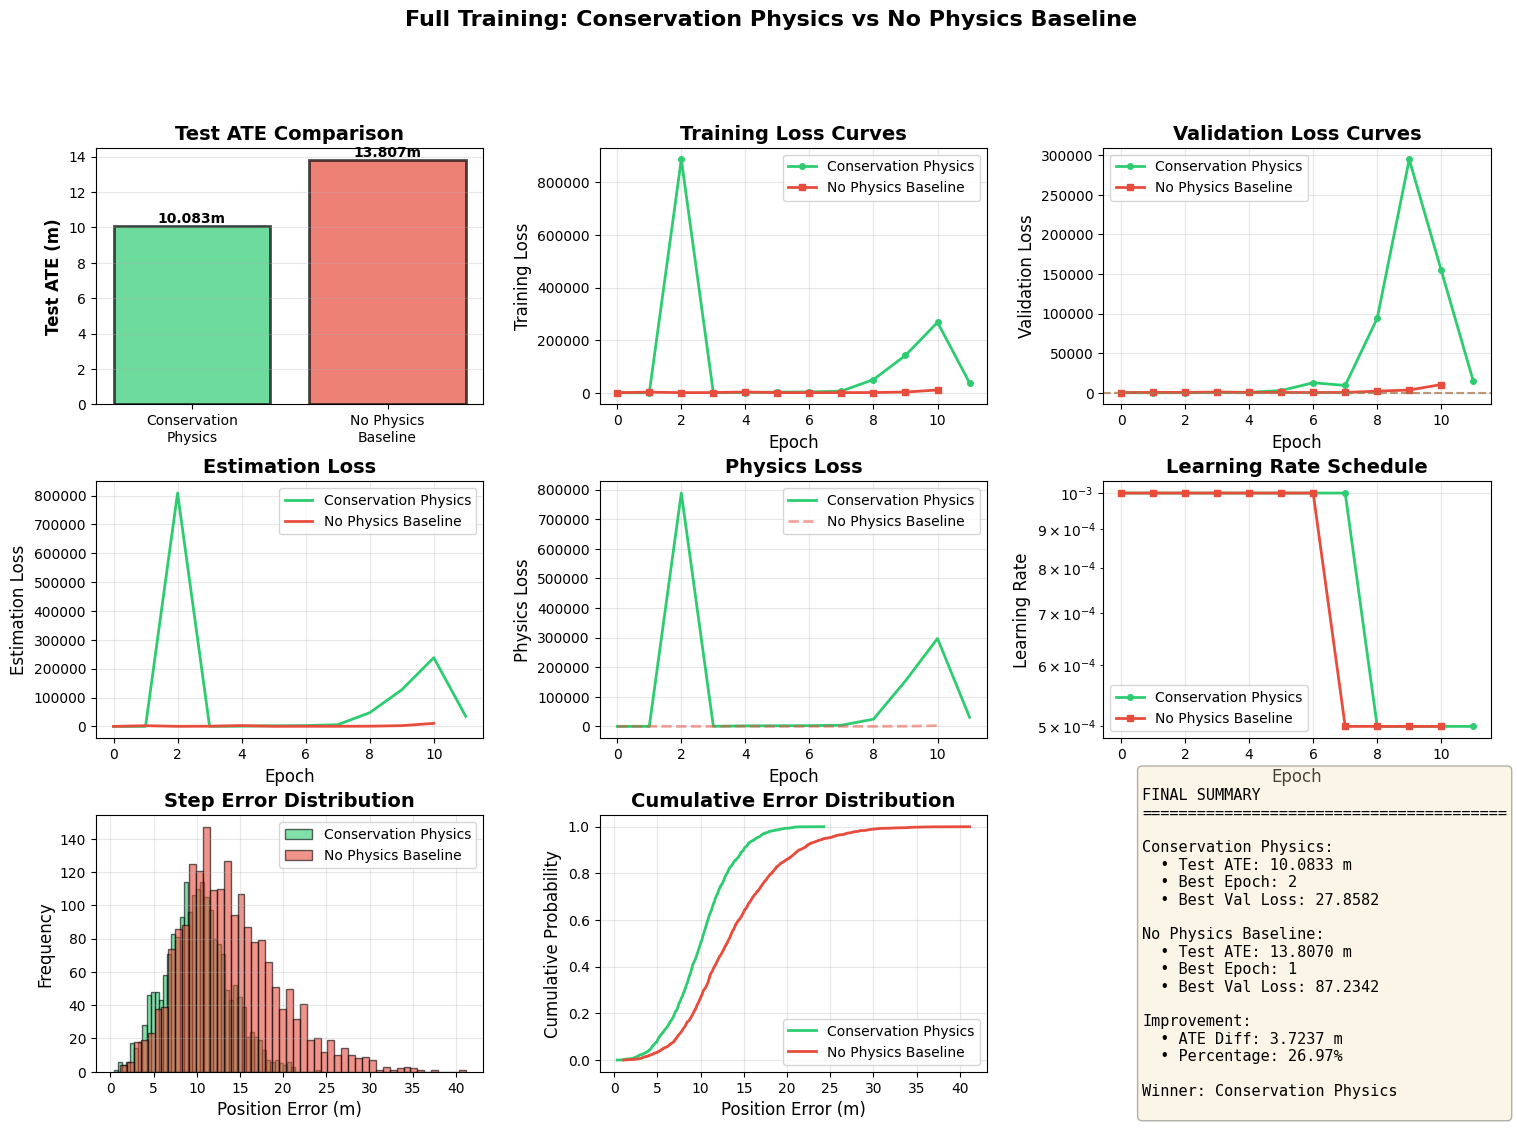


✓ Plots saved to: /content/PIDSE/experiments/conservation_vs_baseline_20251209_081959/full_training_comparison.png


: 

In [ ]:
# Create comprehensive plots
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Test ATE Comparison
ax1 = fig.add_subplot(gs[0, 0])
models = ['Conservation\nPhysics', 'No Physics\nBaseline']
ates = [result_conservation['test_ate'], result_baseline['test_ate']]
colors = ['#2ecc71', '#e74c3c']
bars = ax1.bar(models, ates, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax1.set_ylabel('Test ATE (m)', fontsize=12, fontweight='bold')
ax1.set_title('Test ATE Comparison', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
for bar, ate in zip(bars, ates):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{ate:.3f}m', ha='center', va='bottom', fontweight='bold')

# 2. Training Loss Curves
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(result_conservation['history']['train_loss'], label='Conservation Physics', 
         color='#2ecc71', linewidth=2, marker='o', markersize=4)
ax2.plot(result_baseline['history']['train_loss'], label='No Physics Baseline',
         color='#e74c3c', linewidth=2, marker='s', markersize=4)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Training Loss', fontsize=12)
ax2.set_title('Training Loss Curves', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

# 3. Validation Loss Curves
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(result_conservation['history']['val_loss'], label='Conservation Physics',
         color='#2ecc71', linewidth=2, marker='o', markersize=4)
ax3.plot(result_baseline['history']['val_loss'], label='No Physics Baseline',
         color='#e74c3c', linewidth=2, marker='s', markersize=4)
ax3.axhline(result_conservation['best_val_loss'], color='#2ecc71', linestyle='--', alpha=0.5)
ax3.axhline(result_baseline['best_val_loss'], color='#e74c3c', linestyle='--', alpha=0.5)
ax3.set_xlabel('Epoch', fontsize=12)
ax3.set_ylabel('Validation Loss', fontsize=12)
ax3.set_title('Validation Loss Curves', fontsize=14, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(alpha=0.3)

# 4. Estimation Loss
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(result_conservation['history']['estimation_loss'], label='Conservation Physics',
         color='#2ecc71', linewidth=2)
ax4.plot(result_baseline['history']['estimation_loss'], label='No Physics Baseline',
         color='#e74c3c', linewidth=2)
ax4.set_xlabel('Epoch', fontsize=12)
ax4.set_ylabel('Estimation Loss', fontsize=12)
ax4.set_title('Estimation Loss', fontsize=14, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(alpha=0.3)

# 5. Physics Loss
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(result_conservation['history']['physics_loss'], label='Conservation Physics',
         color='#2ecc71', linewidth=2)
ax5.plot(result_baseline['history']['physics_loss'], label='No Physics Baseline',
         color='#e74c3c', linewidth=2, linestyle='--', alpha=0.5)
ax5.set_xlabel('Epoch', fontsize=12)
ax5.set_ylabel('Physics Loss', fontsize=12)
ax5.set_title('Physics Loss', fontsize=14, fontweight='bold')
ax5.legend(fontsize=10)
ax5.grid(alpha=0.3)

# 6. Learning Rate
ax6 = fig.add_subplot(gs[1, 2])
ax6.plot(result_conservation['history']['learning_rate'], label='Conservation Physics',
         color='#2ecc71', linewidth=2, marker='o', markersize=4)
ax6.plot(result_baseline['history']['learning_rate'], label='No Physics Baseline',
         color='#e74c3c', linewidth=2, marker='s', markersize=4)
ax6.set_xlabel('Epoch', fontsize=12)
ax6.set_ylabel('Learning Rate', fontsize=12)
ax6.set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
ax6.set_yscale('log')
ax6.legend(fontsize=10)
ax6.grid(alpha=0.3)

# 7. Step Error Distribution
ax7 = fig.add_subplot(gs[2, 0])
ax7.hist(result_conservation['step_errors'], bins=50, alpha=0.6, label='Conservation Physics',
         color='#2ecc71', edgecolor='black')
ax7.hist(result_baseline['step_errors'], bins=50, alpha=0.6, label='No Physics Baseline',
         color='#e74c3c', edgecolor='black')
ax7.set_xlabel('Position Error (m)', fontsize=12)
ax7.set_ylabel('Frequency', fontsize=12)
ax7.set_title('Step Error Distribution', fontsize=14, fontweight='bold')
ax7.legend(fontsize=10)
ax7.grid(alpha=0.3)

# 8. Cumulative Error
ax8 = fig.add_subplot(gs[2, 1])
sorted_errors_cons = np.sort(result_conservation['step_errors'])
sorted_errors_base = np.sort(result_baseline['step_errors'])
ax8.plot(sorted_errors_cons, np.arange(len(sorted_errors_cons))/len(sorted_errors_cons),
         label='Conservation Physics', color='#2ecc71', linewidth=2)
ax8.plot(sorted_errors_base, np.arange(len(sorted_errors_base))/len(sorted_errors_base),
         label='No Physics Baseline', color='#e74c3c', linewidth=2)
ax8.set_xlabel('Position Error (m)', fontsize=12)
ax8.set_ylabel('Cumulative Probability', fontsize=12)
ax8.set_title('Cumulative Error Distribution', fontsize=14, fontweight='bold')
ax8.legend(fontsize=10)
ax8.grid(alpha=0.3)

# 9. Summary Stats
ax9 = fig.add_subplot(gs[2, 2])
ax9.axis('off')
summary_text = f"""
FINAL SUMMARY
{'='*40}

Conservation Physics:
  • Test ATE: {result_conservation['test_ate']:.4f} m
  • Best Epoch: {result_conservation['best_epoch']}
  • Best Val Loss: {result_conservation['best_val_loss']:.4f}

No Physics Baseline:
  • Test ATE: {result_baseline['test_ate']:.4f} m
  • Best Epoch: {result_baseline['best_epoch']}
  • Best Val Loss: {result_baseline['best_val_loss']:.4f}

Improvement:
  • ATE Diff: {ate_improvement:.4f} m
  • Percentage: {ate_improvement_pct:.2f}%
  
Winner: {results_json['comparison']['winner']}
"""
ax9.text(0.1, 0.5, summary_text, fontsize=11, verticalalignment='center',
         fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.suptitle('Full Training: Conservation Physics vs No Physics Baseline', 
             fontsize=16, fontweight='bold', y=0.995)

plots_file = output_dir / 'full_training_comparison.png'
plt.savefig(plots_file, dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Plots saved to: {plots_file}")

## Download Results (Colab)

In [ ]:
if IN_COLAB:
    print("📥 Results files in Colab:")
    print(f"\nOutput directory: {output_dir}")
    
    # List all files
    print("\nGenerated files:")
    for file in sorted(output_dir.glob('*')):
        print(f"  • {file.name}")
    
    # Display JSON results
    results_file = output_dir / 'full_training_results.json'
    if results_file.exists():
        with open(results_file, 'r') as f:
            results_content = f.read()
        print(f"\n--- Results JSON ({len(results_content)} chars) ---")
        print("Copy this JSON content:")
        print(results_content)
    
    print("\n✅ To download files:")
    print("1. Click the folder icon in the left sidebar")
    print(f"2. Navigate to: experiments/{output_dir.name}/")
    print("3. Right-click each file → Download")
    print("\nFiles to download:")
    print("  • full_training_results.json (metrics and history)")
    print("  • full_training_comparison.png (visualization)")
    print("  • conservation_physics_best.pth (best model)")
    print("  • no_physics_baseline_best.pth (baseline model)")
else:
    print(f"✓ All results saved locally at: {output_dir}")
    print(f"\nFiles created:")
    for file in sorted(output_dir.glob('*')):
        print(f"  • {file.name}")

📥 Results files in Colab:

Output directory: /content/PIDSE/experiments/conservation_vs_baseline_20251209_081959

Generated files:
  • conservation_physics_best.pth
  • conservation_physics_epoch10.pth
  • conservation_physics_epoch5.pth
  • full_training_comparison.png
  • full_training_results.json
  • no_physics_baseline_best.pth
  • no_physics_baseline_epoch10.pth
  • no_physics_baseline_epoch5.pth

--- Results JSON (4410 chars) ---
Copy this JSON content:
{
  "config": {
    "state_dim": 12,
    "control_dim": 4,
    "measurement_dim": 9,
    "hidden_dim": 64,
    "num_epochs": 25,
    "batch_size": 32,
    "learning_rate": 0.001,
    "physics_weight": 0.1,
    "device": "cuda",
    "seed": 42,
    "save_interval": 5,
    "patience": 10
  },
  "dataset": "Synthetic",
  "timestamp": "20251209_081959",
  "models": [
    {
      "name": "Conservation Physics",
      "test_ate": 10.08327865600586,
      "test_loss": 28.867956161499023,
      "best_epoch": 2,
      "best_val_loss": 27.

: 